# DenseNet-121 Natural-Orientation CE Training with Grad-CAM

This notebook trains a standard DenseNet-121 classifier on labeled Kaggle knee
ROIs. Grad-CAM is generated only after checkpoint selection and does not affect
the loss, validation score, or checkpoint choice. The final audit compares every
failed map with its original image and exact processed input.


## 0. Import lib
Import library, load device, connect to google drive

In [ ]:
import os
import hashlib
import copy
from collections import Counter
from typing import List, Union
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import tqdm
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Try mounting drive (if on Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except ImportError:
    print("Not running in Google Colab. Skipping Drive mount.")

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Install timm if needed
try:
    import timm
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "timm"])
    import timm

# Install torchmetrics if needed
try:
    import torchmetrics
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "torchmetrics"])
    import torchmetrics

# Install seaborn if needed
try:
    import seaborn
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "seaborn"])
    import seaborn

Mounted at /content/drive
Google Drive mounted successfully.
Using device: cuda
GPU Name: Tesla T4


## 1. Prepare dataset 
unzip dataset from google drive 

In [ ]:
import subprocess
import os
import torch
import numpy as np
from datetime import datetime, timezone

dataset_zip = "/content/drive/MyDrive/Datasets/kaggle_knee_osteoarthritis.zip"
if os.path.exists(dataset_zip):
    print("Unzipping dataset from Google Drive...")
    subprocess.run(
        ["unzip", "-q", "-o", dataset_zip, "-d", "/content/Datasets"],
        check=True,
    )
else:
    print("Zip file not found at default Drive path. Assuming local dataset path.")


class TrainingConfig:
    # Fixed production-candidate architecture
    model_name = "densenet121"
    architecture = "timm_densenet121_linear_gradcam"
    pretrained = True
    num_classes = 5

    # Data and isolated checkpoint directory
    dataset_root = "/content/Datasets/kaggle_knee_osteoarthritis"
    checkpoint_root = "/content/drive/MyDrive/Models/densenet121_checkpoints"
    run_timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%d_%H-%M-%S_%f_UTC")
    checkpoint_dir = os.path.join(
        checkpoint_root,
        f"{run_timestamp}_natural_orientation_ce_gradcam",
    )
    img_size = 384
    crop_size = 384
    batch_size = 48
    num_workers = 4
    seed = 42
    use_amp = True

    # Full natural-orientation ROI; mirroring is training augmentation only.
    canonicalize_laterality = False
    horizontal_flip_p = 0.50
    rotation_degrees = 5
    brightness_jitter = 0.08
    contrast_jitter = 0.08
    random_erasing_p = 0.10
    random_erasing_second_p = 0.0
    clahe_clip_limit = 1.25
    classifier_dropout = 0.20
    gradcam_max_failure_rate_for_roi_hypothesis = 0.10
    clahe_clip_limit = 1.25
    classifier_dropout = 0.20
    gradcam_max_failure_rate_for_roi_hypothesis = 0.10
    gamma_probability = 0.0
    gamma_range = (1.0, 1.0)
    gaussian_noise_probability = 0.0
    use_tta = False

    # Full inverse-frequency sampling won the controlled sampler comparisons.
    use_balanced_sampler = True
    sampler_power = 1.0
    use_minority_aug = False

    # Raw weights: EMA caused the completed natural-orientation collapse.
    use_ema = False
    ema_decay = None

    # Fixed three-stage schedule
    training_pipeline = "3-stage"
    resume_from_last = False
    use_early_stopping = False
    early_stopping_patience_stage2 = 15
    early_stopping_patience_stage3 = 10
    stage1_epochs = 5
    stage2_epochs = 15
    stage3_epochs = 10
    total_epochs_standard = 30

    lr_warmup = 3e-4
    lr_coarse_head = 3e-4
    lr_coarse_backbone = 3e-5
    lr_finetune = 1e-5
    lr_standard = 3e-4
    weight_decay = 1e-4

    # The controlled loss ablation selected five-class cross-entropy.
    loss_stage1 = "ce"
    loss_stage2 = "ce"
    loss_stage3 = "ce"
    loss_standard = "ce"
    ordinal_pd2_weight = 0.0

    # Validation-only checkpoint selector; Grade-1 recall is reported, not rewarded.
    selection_qwk_weight = 0.55
    selection_macro_f1_weight = 0.30
    selection_macro_recall_weight = 0.0
    selection_grade1_recall_weight = 0.0
    selection_macro_ap_weight = 0.15
    selection_macro_auc_weight = 0.0

    scheduler_stage2 = "cosine"
    scheduler_stage3 = "cosine"
    scheduler_standard = "cosine"


def log_config(config):
    print("=" * 65)
    print(" ACTIVE TRAINING CONFIGURATION LOG")
    print("=" * 65)
    attrs = [
        attr for attr in dir(config)
        if not attr.startswith("__") and not callable(getattr(config, attr))
    ]
    for attr in attrs:
        print(f"{attr:<32} : {getattr(config, attr)}")
    print("=" * 65)


log_config(TrainingConfig)

DATASET_ROOT_PATH = TrainingConfig.dataset_root
CHECKPOINT_SAVE_DIR = TrainingConfig.checkpoint_dir
BATCH_SIZE = TrainingConfig.batch_size
IMG_SIZE = TrainingConfig.img_size
CROP_SIZE = TrainingConfig.crop_size

torch.manual_seed(TrainingConfig.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TrainingConfig.seed)
np.random.seed(TrainingConfig.seed)
import random
random.seed(TrainingConfig.seed)

os.makedirs(CHECKPOINT_SAVE_DIR, exist_ok=False)


Unzipping dataset from Google Drive...
 ACTIVE TRAINING CONFIGURATION LOG
architecture                     : timm_densenet121_linear_gradcam
batch_size                       : 48
brightness_jitter                : 0.08
canonicalize_laterality          : False
checkpoint_dir                   : /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-27_04-05-44_234349_UTC_natural_orientation_ce_gradcam
checkpoint_root                  : /content/drive/MyDrive/Models/densenet121_checkpoints
clahe_clip_limit                 : 1.25
classifier_dropout               : 0.2
contrast_jitter                  : 0.08
crop_size                        : 384
dataset_root                     : /content/Datasets/kaggle_knee_osteoarthritis
early_stopping_patience_stage2   : 15
early_stopping_patience_stage3   : 10
ema_decay                        : None
gamma_probability                : 0.0
gamma_range                      : (1.0, 1.0)
gaussian_noise_probability       : 0.0
gradcam_max_failure_ra

## 2. Train config loader
Load train config from input user + seed

In [ ]:
# =========================================================================
# CONFIGURATION & PARAMETERS (Unified Input Config)
# =========================================================================
# TrainingConfig has been unified and defined in Section 1 (Cell 4) 
# to prevent redundant redefinition and early stopping bugs.

# Log configurations
log_config(TrainingConfig)

# Set global alias variables for compatibility with downstream cells
DATASET_ROOT_PATH = TrainingConfig.dataset_root
CHECKPOINT_SAVE_DIR = TrainingConfig.checkpoint_dir
BATCH_SIZE = TrainingConfig.batch_size
IMG_SIZE = TrainingConfig.img_size

# Set random seed for reproducibility
torch.manual_seed(TrainingConfig.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(TrainingConfig.seed)
np.random.seed(TrainingConfig.seed)
import random
random.seed(TrainingConfig.seed)

os.makedirs(CHECKPOINT_SAVE_DIR, exist_ok=True)


 ACTIVE TRAINING CONFIGURATION LOG
architecture                     : timm_densenet121_linear_gradcam
batch_size                       : 48
brightness_jitter                : 0.08
canonicalize_laterality          : False
checkpoint_dir                   : /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-27_04-05-44_234349_UTC_natural_orientation_ce_gradcam
checkpoint_root                  : /content/drive/MyDrive/Models/densenet121_checkpoints
clahe_clip_limit                 : 1.25
classifier_dropout               : 0.2
contrast_jitter                  : 0.08
crop_size                        : 384
dataset_root                     : /content/Datasets/kaggle_knee_osteoarthritis
early_stopping_patience_stage2   : 15
early_stopping_patience_stage3   : 10
ema_decay                        : None
gamma_probability                : 0.0
gamma_range                      : (1.0, 1.0)
gaussian_noise_probability       : 0.0
gradcam_max_failure_rate_for_roi_hypothesis : 0.1
horizontal_

## 3. Image preprocessing

The deterministic validation and inference order is **CLAHE 1.25 -> square
padding -> resize 384**. No center crop is used, so marginal osteophytes remain
visible. Training adds only conservative geometric and intensity augmentation.


In [ ]:
class SquarePadOpenCV(object):
    """Pad the full knee ROI to a square without removing edge osteophytes."""

    def __call__(self, image):
        height, width = image.shape[:2]
        side = max(height, width)
        top = (side - height) // 2
        bottom = side - height - top
        left = (side - width) // 2
        right = side - width - left
        return cv2.copyMakeBorder(
            image,
            top,
            bottom,
            left,
            right,
            borderType=cv2.BORDER_CONSTANT,
            value=[0, 0, 0],
        )


class OpenCVCLAHE(object):
    def __init__(self, clip_limit=1.25, tile_grid_size=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid_size = tile_grid_size

    def __call__(self, img_rgb):
        clahe = cv2.createCLAHE(
            clipLimit=self.clip_limit,
            tileGridSize=self.tile_grid_size,
        )
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)
        lightness, channel_a, channel_b = cv2.split(img_lab)
        lightness = clahe.apply(lightness)
        return cv2.cvtColor(
            cv2.merge((lightness, channel_a, channel_b)),
            cv2.COLOR_LAB2RGB,
        )


def get_transforms(img_size=384, crop_size=384):
    """Natural orientation, full ROI, and conservative training-only augmentation."""
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    )
    train_transform = transforms.Compose([
        OpenCVCLAHE(clip_limit=TrainingConfig.clahe_clip_limit),
        SquarePadOpenCV(),
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=TrainingConfig.horizontal_flip_p),
        transforms.RandomRotation(TrainingConfig.rotation_degrees),
        transforms.ColorJitter(
            brightness=TrainingConfig.brightness_jitter,
            contrast=TrainingConfig.contrast_jitter,
        ),
        transforms.Resize((crop_size, crop_size)),
        transforms.ToTensor(),
        transforms.RandomErasing(
            p=TrainingConfig.random_erasing_p,
            scale=(0.02, 0.05),
            ratio=(0.5, 2.0),
            value=0,
        ),
        normalize,
    ])
    val_transform = transforms.Compose([
        OpenCVCLAHE(clip_limit=TrainingConfig.clahe_clip_limit),
        SquarePadOpenCV(),
        transforms.ToPILImage(),
        transforms.Resize((crop_size, crop_size)),
        transforms.ToTensor(),
        normalize,
    ])
    # TTA and minority augmentation are disabled; return deterministic aliases so
    # the established dataloader architecture remains unchanged.
    return train_transform, val_transform, val_transform, train_transform


## 4. Dataset
Load kaggle dataset (apply transform + duplicate remove)

In [ ]:
def remove_duplicate_images(image_paths: list, labels: list, exclude_hashes: set = None):
    """Remove byte-identical images and cross-split duplicates using MD5."""
    total_found = len(image_paths)
    unique_paths, unique_labels, unique_hashes = [], [], set()
    internal_dup_count, leakage_count = 0, 0

    for path, label in zip(image_paths, labels):
        hash_md5 = hashlib.md5()
        try:
            with open(path, "rb") as image_file:
                for chunk in iter(lambda: image_file.read(4096), b""):
                    hash_md5.update(chunk)
            digest = hash_md5.hexdigest()
        except Exception as error:
            print(f"Warning: Could not read image {path}: {error}")
            continue

        if exclude_hashes and digest in exclude_hashes:
            leakage_count += 1
            continue
        if digest in unique_hashes:
            internal_dup_count += 1
            continue

        unique_hashes.add(digest)
        unique_paths.append(path)
        unique_labels.append(label)

    print(
        f"\n--- Deduplication: Files found: {total_found} | "
        f"Unique kept: {len(unique_paths)} | Dupes removed: {internal_dup_count} | "
        f"Cross-split leaks: {leakage_count}"
    )
    return unique_paths, unique_labels, unique_hashes


class KaggleKneeOsteoarthritisDataset(Dataset):
    """Load one split while preserving each image in its natural orientation."""

    def __init__(self, root: str, split_dir: str, transform=None, exclude_hashes: set = None, minority_transform=None):
        self.root = root
        self.transform = transform
        self.minority_transform = minority_transform
        raw_paths, raw_labels = [], []
        split_path = os.path.join(root, split_dir)

        if not os.path.isdir(split_path):
            raise FileNotFoundError(f"Split directory not found: {split_path}")

        class_names = sorted(
            directory for directory in os.listdir(split_path)
            if os.path.isdir(os.path.join(split_path, directory)) and directory.isdigit()
        )
        print(f"Loading '{split_dir}' split from: {split_path}")

        for class_name in class_names:
            class_dir = os.path.join(split_path, class_name)
            label = int(class_name)
            valid_extensions = (".png", ".jpg", ".jpeg")
            image_files = [
                filename for filename in os.listdir(class_dir)
                if filename.lower().endswith(valid_extensions)
            ]
            for filename in image_files:
                raw_paths.append(os.path.join(class_dir, filename))
                raw_labels.append(label)

        self.image_paths, self.labels, self.image_hashes = remove_duplicate_images(
            raw_paths, raw_labels, exclude_hashes=exclude_hashes
        )

    def load_image_from_path(self, image_path: str) -> np.ndarray:
        image_bgr = cv2.imread(image_path)
        if image_bgr is None:
            raise IOError(f"Could not read image: {image_path}")
        image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return image

    def __getitem__(self, index: int):
        image = self.load_image_from_path(self.image_paths[index])
        label = self.labels[index]
        if self.minority_transform and label in [3, 4]:
            image = self.minority_transform(image)
        elif self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self) -> int:
        return len(self.image_paths)


## 5. Dataloader
Prepare train, val dataloader

In [ ]:
# Create transforms
train_transform, val_transform, val_transform_tta, minority_train_transform = get_transforms(
    img_size=TrainingConfig.img_size, crop_size=TrainingConfig.crop_size
)
val_loader_transform = val_transform_tta if TrainingConfig.use_tta else val_transform

# Determine minority transform based on configuration
minor_transform = minority_train_transform if TrainingConfig.use_minority_aug else None

# Load training dataset
train_dataset = KaggleKneeOsteoarthritisDataset(
    root=DATASET_ROOT_PATH, split_dir="train", transform=train_transform, minority_transform=minor_transform
)
train_hashes = set(train_dataset.image_hashes)

# Load validation dataset
val_split_dir = "val"
if not os.path.isdir(os.path.join(DATASET_ROOT_PATH, val_split_dir)):
    raise FileNotFoundError("A validation split is required; test fallback is disabled.")
val_dataset = KaggleKneeOsteoarthritisDataset(
    root=DATASET_ROOT_PATH, split_dir=val_split_dir, transform=val_loader_transform, exclude_hashes=train_hashes
)

# Imbalance handling: Calculate Class-Aware WeightedRandomSampler for training split
from torch.utils.data import WeightedRandomSampler

# Count samples of each class
class_counts = Counter(train_dataset.labels)
print(f"Training class distribution: {dict(sorted(class_counts.items()))}")

# Create training loader based on config
if TrainingConfig.use_balanced_sampler:
    print("Using WeightedRandomSampler for class balance.")
    class_weights = {
        cls: 1.0 / (count ** TrainingConfig.sampler_power)
        for cls, count in class_counts.items()
    }
    sample_weights = [class_weights[label] for label in train_dataset.labels]
    sampler_generator = torch.Generator().manual_seed(TrainingConfig.seed)
    loader_generator = torch.Generator().manual_seed(TrainingConfig.seed)
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=sampler_generator,
    )
    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=TrainingConfig.num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=TrainingConfig.num_workers > 0,
        generator=loader_generator,
    )
else:
    print("Using standard shuffled DataLoader.")
    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=TrainingConfig.num_workers,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=TrainingConfig.num_workers > 0,
        generator=torch.Generator().manual_seed(TrainingConfig.seed),
    )

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=TrainingConfig.num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=TrainingConfig.num_workers > 0,
)

print(f"Data loaders ready. Train batches: {len(train_loader)} | Validation batches: {len(val_loader)}")

Loading 'train' split from: /content/Datasets/kaggle_knee_osteoarthritis/train

--- Deduplication: Files found: 5778 | Unique kept: 5778 | Dupes removed: 0 | Cross-split leaks: 0
Loading 'val' split from: /content/Datasets/kaggle_knee_osteoarthritis/val

--- Deduplication: Files found: 826 | Unique kept: 826 | Dupes removed: 0 | Cross-split leaks: 0
Training class distribution: {0: 2286, 1: 1046, 2: 1516, 3: 757, 4: 173}
Using WeightedRandomSampler for class balance.
Data loaders ready. Train batches: 121 | Validation batches: 18


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 6. CORAL & CORN convert label
Normal Ce: 5 class -> CORAL: 4 class

In [ ]:
def label_to_levels(label, num_classes, dtype=torch.float32):
    # Converts class label index to binary level vector
    batch_size = label.size(0)

    # create a full zeros matrix size: batch x num_classes
    levels = torch.zeros(batch_size, num_classes - 1, dtype=dtype, device=label.device)

    # convert label to rank constraints
    for i in range(batch_size):
        levels[i, :label[i]] = 1.0
    return levels

# avg of all coral loss 
def coral_loss(logits, y_train, num_classes=5):
    levels = label_to_levels(y_train, num_classes)
    loss = F.binary_cross_entropy_with_logits(logits, levels)
    return loss

# get final label
def coral_label_from_logits(logits):
    probs = torch.sigmoid(logits)
    predicted = (probs > 0.5).sum(dim=1)
    return predicted

# get corn loss     
def corn_loss(logits, y_train, num_classes=5, task_weights=[2.0, 1.8, 1.2, 1.0]):
    loss = 0.0
    num_tasks = num_classes - 1
    for k in range(num_tasks):

        # get image which has class >= k [True, False, True, ...]
        mask = y_train >= k
        if not mask.any():
            continue

        # get logit which class >= k
        logits_k = logits[mask, k]

        # get label format [1,0] for each image
        targets_k = (y_train[mask] > k).float()
        # Apply label smoothing (0.1)
        targets_k = targets_k * (1 - 0.1) + (1 - targets_k) * 0.1

        # calc loss 
        # Apply task-specific weight to balance gradients for minority classes
        w_k = task_weights[k] if k < len(task_weights) else 1.0
        loss += w_k * F.binary_cross_entropy_with_logits(logits_k, targets_k)

    # get avg
    return loss / num_tasks

def focal_corn_loss(logits, y_train, num_classes=5, gamma=2.0, alpha=0.25, task_weights=[2.0, 1.8, 1.2, 1.0]):

    # similar to corn loss 
    loss = 0.0
    num_tasks = num_classes - 1
    for k in range(num_tasks):
        mask = y_train >= k
        if not mask.any():
            continue
        logits_k = logits[mask, k]
        targets_k = (y_train[mask] > k).float()
        # Apply label smoothing (0.1)
        targets_k = targets_k * (1 - 0.1) + (1 - targets_k) * 0.1
        

        # load bce for each image (do not calc avg)
        bce = F.binary_cross_entropy_with_logits(logits_k, targets_k, reduction='none')


        p = torch.sigmoid(logits_k)
        
        # Calculate focal modulation weight
        p_t = p * targets_k + (1 - p) * (1 - targets_k)
        focal_weight = alpha * (1 - p_t) ** gamma
        
        w_k = task_weights[k] if k < len(task_weights) else 1.0
        loss += w_k * (focal_weight * bce).mean()
    return loss / num_tasks

def corn_probas(logits):
    # calc prob 
    cond_probas = torch.sigmoid(logits)

    batch_size = logits.size(0)
    num_classes = logits.size(1) + 1

    # probas = [0,0,0,0]
    probas = torch.zeros(batch_size, num_classes, device=logits.device)

    # cumpprod : A, A*B, A*B*C
    cumprod = torch.cumprod(cond_probas, dim=1)


    # calc final class prediction 
    probas[:, 0] = 1.0 - cond_probas[:, 0]
    for i in range(1, num_classes - 1):
        probas[:, i] = cumprod[:, i - 1] * (1.0 - cond_probas[:, i])
    probas[:, -1] = cumprod[:, -1]
    return probas

def corn_label_from_logits(logits):
    probas = corn_probas(logits)
    return torch.argmax(probas, dim=1)



def adjustable_ordinal_pd2_loss(logits, targets):
    """Normalized five-logit PD-2 loss for ordered KL grades."""
    probabilities = F.softmax(logits.float(), dim=1)
    grades = torch.arange(logits.size(1), device=logits.device)
    distance = (grades[None, :] - targets[:, None]).abs().float()
    expected_pd2 = (probabilities * (2.0 * distance)).sum(dim=1)
    max_pd2 = 2.0 * (logits.size(1) - 1)
    return (expected_pd2 / max_pd2).square().mean()


## 7. Model

DenseNet-121 uses its standard global-average-pooling and linear classification
head. The final `features.norm5` activation is the Grad-CAM target. There is no
native-CAM head and no localization term in the training objective.


In [ ]:
class DenseNet121Model(nn.Module):
    """Standard timm DenseNet-121 classifier; Grad-CAM is post-hoc only."""

    def __init__(self, num_classes: int = 5, pretrained: bool = True, loss_type: str = "ce"):
        super().__init__()
        if loss_type not in {"ce", "ordinal_pd2", "ce_plus_ordinal_pd2"}:
            raise ValueError(f"Unsupported five-logit loss: {loss_type}")

        self.num_classes = num_classes
        self.backbone = timm.create_model(
            "densenet121",
            pretrained=pretrained,
            num_classes=num_classes,
            drop_rate=TrainingConfig.classifier_dropout,
        )
        self.use_amp = bool(TrainingConfig.use_amp and torch.cuda.is_available())
        self.grad_scaler = torch.amp.GradScaler("cuda", enabled=self.use_amp)

    def head_parameters(self):
        return self.backbone.classifier.parameters()

    @property
    def gradcam_target_layer(self):
        return self.backbone.features.norm5

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        if images.ndim == 5:
            batch_size, crops, channels, height, width = images.shape
            logits = self.backbone(images.reshape(-1, channels, height, width))
            return logits.reshape(batch_size, crops, -1).mean(dim=1)
        return self.backbone(images)

    def freeze_backbone(self):
        print("Freezing DenseNet-121 features; training the linear classifier only.")
        for parameter in self.backbone.parameters():
            parameter.requires_grad = False
        for parameter in self.head_parameters():
            parameter.requires_grad = True

    def unfreeze_last_block(self):
        print("Unfreezing denseblock3, denseblock4, norm5, and the classifier.")
        for parameter in self.parameters():
            parameter.requires_grad = False
        for name, module in self.backbone.named_modules():
            if "denseblock3" in name or "denseblock4" in name or "norm5" in name:
                for parameter in module.parameters():
                    parameter.requires_grad = True
        for parameter in self.head_parameters():
            parameter.requires_grad = True

    def unfreeze_backbone(self):
        print("Unfreezing the full standard DenseNet-121 classifier.")
        for parameter in self.parameters():
            parameter.requires_grad = True

    def fit(self, epoch, data_loader, optimizer, loss_type, device, ema=None):
        self.to(device)
        self.train()
        running_loss, total, correct = 0.0, 0, 0
        criterion = get_loss_criterion(loss_type, num_classes=self.num_classes)
        progress_bar = tqdm.tqdm(data_loader, desc=f"Epoch {epoch + 1} [TRAIN]")

        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=self.use_amp):
                outputs = self(images)
                loss = criterion(outputs, labels)
            self.grad_scaler.scale(loss).backward()
            self.grad_scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(self.parameters(), max_norm=1.0)
            self.grad_scaler.step(optimizer)
            self.grad_scaler.update()
            if ema is not None:
                ema.update(self)

            running_loss += loss.item() * labels.size(0)
            predictions = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += (predictions == labels).sum().item()
            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}", acc=f"{100.0 * correct / total:.2f}%"
            )

        return running_loss / total, 100.0 * correct / total

    def evaluate(self, epoch, data_loader, loss_type, device, description="VALIDATE"):
        from sklearn.metrics import (
            average_precision_score,
            cohen_kappa_score,
            precision_recall_fscore_support,
            recall_score,
            roc_auc_score,
        )

        self.to(device)
        self.eval()
        running_loss, total, correct = 0.0, 0, 0
        all_predictions, all_labels, all_probabilities = [], [], []
        criterion = get_loss_criterion(loss_type, num_classes=self.num_classes)
        description_text = (
            f"Epoch {epoch + 1} [{description}]" if epoch is not None else description
        )

        with torch.no_grad():
            for images, labels in tqdm.tqdm(data_loader, desc=description_text):
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with torch.amp.autocast(device_type=device.type, enabled=self.use_amp):
                    outputs = self(images)
                    loss = criterion(outputs, labels)
                probabilities = F.softmax(outputs.float(), dim=1)
                predictions = probabilities.argmax(dim=1)
                running_loss += loss.item() * labels.size(0)
                total += labels.size(0)
                correct += (predictions == labels).sum().item()
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                all_probabilities.extend(probabilities.cpu().numpy())

        labels_array = np.asarray(all_labels)
        predictions_array = np.asarray(all_predictions)
        probabilities_array = np.asarray(all_probabilities)
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
            labels_array, predictions_array, average="macro", zero_division=0
        )
        grade1_recall = recall_score(
            labels_array == 1, predictions_array == 1, zero_division=0
        )
        one_hot = np.eye(self.num_classes)[labels_array]
        macro_ap = average_precision_score(one_hot, probabilities_array, average="macro")
        macro_auc = roc_auc_score(one_hot, probabilities_array, average="macro")
        qwk = cohen_kappa_score(labels_array, predictions_array, weights="quadratic")
        report = classification_report(
            labels_array,
            predictions_array,
            target_names=[str(index) for index in range(self.num_classes)],
            zero_division=0,
        )

        print(f"\nQuadratic Weighted Kappa (QWK): {qwk:.4f}")
        print(f"Macro F1 / Recall: {macro_f1:.4f} / {macro_recall:.4f}")
        print(f"Macro AP / AUC: {macro_ap:.4f} / {macro_auc:.4f}")
        return {
            "loss": running_loss / total,
            "acc": 100.0 * correct / total,
            "qwk": float(qwk),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_f1": float(macro_f1),
            "grade1_recall": float(grade1_recall),
            "auc": float(macro_auc),
            "ap": float(macro_ap),
            "probas": probabilities_array,
            "report": report,
        }

class ModelEMA:
    """Maintain an inference-only exponential moving average of model state."""

    def __init__(self, model: nn.Module, decay: float = 0.999):
        if not 0.0 < decay < 1.0:
            raise ValueError("EMA decay must be between 0 and 1.")
        self.decay = float(decay)
        self.module = copy.deepcopy(model).eval()
        self.module.requires_grad_(False)
        self.device = next(model.parameters()).device
        self.module.to(self.device)

    @torch.no_grad()
    def update(self, model: nn.Module):
        model_device = next(model.parameters()).device
        if model_device != self.device:
            self.device = model_device
            self.module.to(self.device)
        source_state = model.state_dict()
        for name, averaged_value in self.module.state_dict().items():
            source_value = source_state[name].detach().to(averaged_value.device)
            if averaged_value.is_floating_point():
                averaged_value.mul_(self.decay).add_(source_value, alpha=1.0 - self.decay)
            else:
                averaged_value.copy_(source_value)

    @torch.no_grad()
    def reset(self, model: nn.Module):
        self.device = next(model.parameters()).device
        self.module.to(self.device)
        self.module.load_state_dict(model.state_dict())
        self.module.eval()



In [ ]:
# Instantiate the standard DenseNet-121 classifier.
initial_loss = TrainingConfig.loss_stage1 if TrainingConfig.training_pipeline in ["2-stage", "3-stage"] else TrainingConfig.loss_standard
model = DenseNet121Model(
    num_classes=TrainingConfig.num_classes,
    pretrained=TrainingConfig.pretrained,
    loss_type=initial_loss,
).to(device)
ema_model = (
    ModelEMA(model, decay=TrainingConfig.ema_decay)
    if TrainingConfig.use_ema else None
)

stage2_best_path = os.path.join(CHECKPOINT_SAVE_DIR, "stage2_best_model.pth")
stage3_best_path = os.path.join(CHECKPOINT_SAVE_DIR, "best_model.pth")
last_model_path = os.path.join(CHECKPOINT_SAVE_DIR, "last_model.pth")

criterion = None
print(
    f"DenseNet-121 initialized: {TrainingConfig.architecture}, natural orientation, "
    f"{initial_loss.upper()}, standard linear classifier, post-hoc Grad-CAM."
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


model.safetensors: reconstructing file:   0%|          |  0.00B / 32.3MB            

model.safetensors: downloading bytes:           |  0.00B            

DenseNet-121 initialized: timm_densenet121_linear_gradcam, natural orientation, CE, standard linear classifier, post-hoc Grad-CAM.


## 8. Prepare for pipeline
Prepare loss, prediction, lr scheduler, pipeline

In [ ]:
best_val_qwk = -1.0
best_val_qwk_stage2 = -1.0
history = []


def get_loss_criterion(loss_type, num_classes=5):
    if loss_type == "ce":
        return nn.CrossEntropyLoss()
    if loss_type == "ordinal_pd2":
        return adjustable_ordinal_pd2_loss
    if loss_type == "ce_plus_ordinal_pd2":
        return lambda logits, targets: (
            F.cross_entropy(logits, targets)
            + TrainingConfig.ordinal_pd2_weight
            * adjustable_ordinal_pd2_loss(logits, targets)
        )
    raise ValueError(f"Unsupported five-logit loss: {loss_type}")


def get_prediction_helper(loss_type):
    if loss_type in {"ce", "ordinal_pd2", "ce_plus_ordinal_pd2"}:
        return lambda logits: torch.argmax(logits, dim=1)
    raise ValueError(f"Unsupported five-logit loss: {loss_type}")


def get_scheduler(scheduler_type, optimizer, epochs):
    if scheduler_type == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs, eta_min=1e-7
        )
    if scheduler_type == "step":
        return optim.lr_scheduler.StepLR(
            optimizer, step_size=max(1, int(epochs * 0.33)), gamma=0.1
        )
    if scheduler_type == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.1, patience=3
        )
    return None


## 9. Execute pipeline
Decide which pipeline will be used ( 1,2 or 3 stage)

In [ ]:
best_val_qwk = -1.0
best_val_qwk_stage2 = -1.0
best_val_selection_score = -1.0
best_val_selection_score_stage2 = -1.0
history = []
start_epoch = 0
train_loader_orig = None

# Define loss helper functions inside the cell to ensure they are available
def get_loss_criterion(loss_type, num_classes=5):
    if loss_type == "ce":
        return nn.CrossEntropyLoss()
    if loss_type == "ordinal_pd2":
        return adjustable_ordinal_pd2_loss
    if loss_type == "ce_plus_ordinal_pd2":
        return lambda logits, targets: (
            F.cross_entropy(logits, targets)
            + TrainingConfig.ordinal_pd2_weight
            * adjustable_ordinal_pd2_loss(logits, targets)
        )
    raise ValueError(f"Unsupported five-logit loss: {loss_type}")


def get_prediction_helper(loss_type):
    if loss_type in {"ce", "ordinal_pd2", "ce_plus_ordinal_pd2"}:
        return lambda logits: torch.argmax(logits, dim=1)
    raise ValueError(f"Unsupported five-logit loss: {loss_type}")


def get_scheduler(scheduler_type, optimizer, epochs):
    if scheduler_type == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-7)
    elif scheduler_type == "step":
        return optim.lr_scheduler.StepLR(optimizer, step_size=int(epochs*0.33), gamma=0.1)
    elif scheduler_type == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    else:
        return None

# Check if we should resume from last checkpoint automatically
resumed = False
stage2_counter = 0
stage3_counter = 0
skip_stage2_flag = False

if getattr(TrainingConfig, "resume_from_last", True) and os.path.exists(last_model_path):
    try:
        print(f"Loading last checkpoint from: {last_model_path} to resume training...")
        # PyTorch 2.6 defaults to weights_only=True. We set it to False to allow custom objects in checkpoint dict.
        try:
            checkpoint = torch.load(last_model_path, map_location=device, weights_only=False)
        except TypeError:
            checkpoint = torch.load(last_model_path, map_location=device)
            
        # Load model weights
        model.load_state_dict(
            checkpoint.get('raw_model_state_dict', checkpoint['model_state_dict'])
        )
        
        if ema_model is not None:
            ema_model.reset(model)
        
        # Load metrics and training history
        history = checkpoint.get('history', [])
        start_epoch = checkpoint.get('epoch', 0)
        best_val_qwk = checkpoint.get('best_val_qwk', -1.0)
        best_val_qwk_stage2 = checkpoint.get('best_val_qwk_stage2', -1.0)
        best_val_selection_score = checkpoint.get('best_val_selection_score', -1.0)
        best_val_selection_score_stage2 = checkpoint.get('best_val_selection_score_stage2', -1.0)
        stage2_counter = checkpoint.get('stage2_counter', 0)
        stage3_counter = checkpoint.get('stage3_counter', 0)
        skip_stage2_flag = checkpoint.get('skip_stage2_flag', False)
        
        print(f"Successfully resumed from Epoch {start_epoch + 1}. Previous best QWK: {best_val_qwk:.4f}")
        resumed = True
    except Exception as e:
        print(f"Could not automatically resume from last checkpoint: {e}. Starting fresh.")

# Execute pipeline based on configuration
pipeline = TrainingConfig.training_pipeline
stage1_epochs = TrainingConfig.stage1_epochs
stage2_epochs = TrainingConfig.stage2_epochs
stage3_epochs = TrainingConfig.stage3_epochs
total_epochs = stage1_epochs + stage2_epochs + stage3_epochs if pipeline == "3-stage" else (stage1_epochs + stage2_epochs if pipeline == "2-stage" else TrainingConfig.total_epochs_standard)

current_stage = None
optimizer = None
scheduler = None

# If we resumed, we will skip epoch iterations before start_epoch
for epoch in range(start_epoch, total_epochs):
    # If early stopping triggered transition, skip remaining epochs of Stage 2
    if pipeline == "3-stage" and skip_stage2_flag and epoch < stage1_epochs + stage2_epochs:
        continue

    # Determine stage and configure optimizer dynamically based on epoch index
    if pipeline == "3-stage":
        if epoch < stage1_epochs:
            stage_name = "Stage 1"
            loss_type = TrainingConfig.loss_stage1
            if current_stage != "Stage 1":
                print("\n=== CONFIGURING STAGE 1: WARM-UP FC (Backbone Frozen) ===")
                model.freeze_backbone()
                optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=TrainingConfig.lr_warmup, weight_decay=TrainingConfig.weight_decay)
                current_stage = "Stage 1"
        elif epoch < stage1_epochs + stage2_epochs:
            stage_name = "Stage 2"
            loss_type = TrainingConfig.loss_stage2
            if current_stage != "Stage 2":
                print("\n=== CONFIGURING STAGE 2: COARSE-TUNING (Last Dense Block Unfrozen, Balanced Data) ===")
                model.unfreeze_last_block()
                head_parameter_ids = {id(parameter) for parameter in model.head_parameters()}
                backbone_params = [
                    parameter for parameter in model.backbone.parameters()
                    if parameter.requires_grad and id(parameter) not in head_parameter_ids
                ]
                optimizer = optim.AdamW([
                    {'params': backbone_params, 'lr': TrainingConfig.lr_coarse_backbone},
                    {'params': model.head_parameters(), 'lr': TrainingConfig.lr_coarse_head}
                ], weight_decay=TrainingConfig.weight_decay)
                scheduler = get_scheduler(TrainingConfig.scheduler_stage2, optimizer, stage2_epochs)
                
                # Load scheduler state if resumed
                if resumed and checkpoint.get('scheduler_state_dict') is not None:
                    try:
                        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                    except:
                        pass
                current_stage = "Stage 2"
        else:
            stage_name = "Stage 3"
            loss_type = TrainingConfig.loss_stage3
            if current_stage != "Stage 3":
                print("\n=== CONFIGURING STAGE 3: FINE-TUNING (Load Stage 2 Best, Full-Balanced Sampler, CE Loss) ===")
                # Only load Stage 2 best weights if we are transitioning normally or resumed fresh at Stage 3
                if not resumed or epoch == stage1_epochs + stage2_epochs:
                    if os.path.exists(stage2_best_path):
                        print("Loading best Stage 2 model weights...")
                        try:
                            checkpoint_s2 = torch.load(stage2_best_path, map_location=device, weights_only=False)
                        except TypeError:
                            checkpoint_s2 = torch.load(stage2_best_path, map_location=device)
                        model.load_state_dict(checkpoint_s2['model_state_dict'])
                        if ema_model is not None:
                            ema_model.reset(model)
                
                # Keep the full inverse-frequency sampler used by the winning ablation.
                train_dataset.minority_transform = None
                
                model.unfreeze_backbone()
                optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_finetune, weight_decay=10*TrainingConfig.weight_decay)
                scheduler = get_scheduler(TrainingConfig.scheduler_stage3, optimizer, stage3_epochs)
                
                # Load scheduler state if resumed
                if resumed and checkpoint.get('scheduler_state_dict') is not None:
                    try:
                        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                    except:
                        pass
                current_stage = "Stage 3"
                
    elif pipeline == "2-stage":
        if epoch < stage1_epochs:
            stage_name = "Stage 1"
            loss_type = TrainingConfig.loss_stage1
            if current_stage != "Stage 1":
                print("\n=== CONFIGURING STAGE 1: WARM-UP FC (Backbone Frozen) ===")
                model.freeze_backbone()
                optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=TrainingConfig.lr_warmup, weight_decay=TrainingConfig.weight_decay)
                current_stage = "Stage 1"
        else:
            stage_name = "Stage 2"
            loss_type = TrainingConfig.loss_stage2
            if current_stage != "Stage 2":
                print("\n=== CONFIGURING STAGE 2: FULL FINE-TUNING (All Layers Unfrozen) ===")
                model.unfreeze_backbone()
                optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_coarse_head, weight_decay=TrainingConfig.weight_decay)
                scheduler = get_scheduler(TrainingConfig.scheduler_stage2, optimizer, stage2_epochs)
                if resumed and checkpoint.get('scheduler_state_dict') is not None:
                    try:
                        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                    except:
                        pass
                current_stage = "Stage 2"
                
    else:
        stage_name = "Standard"
        loss_type = TrainingConfig.loss_standard
        if current_stage != "Standard":
            print("\n=== CONFIGURING STANDARD FINE-TUNING ===")
            model.unfreeze_backbone()
            optimizer = optim.AdamW(model.parameters(), lr=TrainingConfig.lr_standard, weight_decay=TrainingConfig.weight_decay)
            scheduler = get_scheduler(TrainingConfig.scheduler_standard, optimizer, total_epochs)
            if resumed and checkpoint.get('scheduler_state_dict') is not None:
                try:
                    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
                except:
                    pass
            current_stage = "Standard"

    # Use the same full-balanced sampling policy in every training stage.
    active_loader = train_loader
    
    # Fit & Evaluate
    train_loss, train_acc = model.fit(
        epoch, active_loader, optimizer, loss_type, device,
        ema=ema_model if TrainingConfig.use_ema else None
    )
    validation_model = ema_model.module if TrainingConfig.use_ema else model
    val_metrics = validation_model.evaluate(
        epoch, val_loader, loss_type, device, description="VALIDATE"
    )
    
    val_loss = val_metrics["loss"]
    val_acc = val_metrics["acc"]
    val_report = val_metrics["report"]
    val_qwk = val_metrics["qwk"]
    val_macro_f1 = val_metrics["macro_f1"]
    val_macro_recall = val_metrics["macro_recall"]
    val_grade1_recall = val_metrics["grade1_recall"]
    val_macro_ap = val_metrics["ap"]
    val_macro_auc = val_metrics["auc"]
    val_selection_score = (
        TrainingConfig.selection_qwk_weight * val_qwk
        + TrainingConfig.selection_macro_f1_weight * val_macro_f1
        + TrainingConfig.selection_macro_recall_weight * val_macro_recall
        + TrainingConfig.selection_grade1_recall_weight * val_grade1_recall
        + TrainingConfig.selection_macro_ap_weight * val_macro_ap
        + TrainingConfig.selection_macro_auc_weight * val_macro_auc
    )
    
    if scheduler is not None:
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()
        current_lr = scheduler.get_last_lr()[0]
    else:
        current_lr = optimizer.param_groups[0]['lr']
        
    print(f"\n--- {stage_name} Epoch {epoch+1}/{total_epochs} ---")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | Val QWK: {val_qwk:.4f} | "
        f"Macro F1/Recall: {val_macro_f1:.4f}/{val_macro_recall:.4f} | "
        f"Grade 1 Recall: {val_grade1_recall:.4f} | AP/AUC: {val_macro_ap:.4f}/{val_macro_auc:.4f} | "
        f"Selection: {val_selection_score:.4f} | LR: {current_lr:.7f}"
    )
    
    history.append({
        "stage": stage_name, "epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc, "qwk": val_qwk,
        "macro_precision": val_metrics["macro_precision"],
        "macro_recall": val_macro_recall, "macro_f1": val_macro_f1,
        "grade1_recall": val_grade1_recall, "selection_score": val_selection_score,
        "auc": val_macro_auc, "ap": val_macro_ap
    })
    
    # Keep checkpoint metadata compact and JSON-safe for the final manifest.
    checkpoint_validation_metrics = {
        key: value
        for key, value in val_metrics.items()
        if key not in {"probas", "report"}
    }
    checkpoint_validation_metrics["selection_score"] = float(val_selection_score)

    # Prepare checkpoint dictionary
    checkpoint_state = {
        'epoch': epoch + 1,
        # Best checkpoints use the exact raw weights evaluated above.
        'model_state_dict': validation_model.state_dict(),
        # Kept as a compatibility alias for established checkpoint readers.
        'raw_model_state_dict': model.state_dict(),
        'ema_decay': None,
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'best_val_qwk': best_val_qwk,
        'best_val_qwk_stage2': best_val_qwk_stage2,
        'best_val_selection_score': best_val_selection_score,
        'best_val_selection_score_stage2': best_val_selection_score_stage2,
        'history': history,
        'stage2_counter': stage2_counter,
        'stage3_counter': stage3_counter,
        'skip_stage2_flag': skip_stage2_flag,
        'model_name': TrainingConfig.model_name,
        'architecture': TrainingConfig.architecture,
        'loss_type': loss_type,
        'run_timestamp': TrainingConfig.run_timestamp,
        'validation_metrics': checkpoint_validation_metrics,
        'training_config': {
            key: getattr(TrainingConfig, key) for key in dir(TrainingConfig)
            if not key.startswith('__') and not callable(getattr(TrainingConfig, key))
        },
    }
    
    # Save best Stage 2 model and check early stopping
    if stage_name == "Stage 2":
        if val_selection_score > best_val_selection_score_stage2:
            best_val_selection_score_stage2 = val_selection_score
            best_val_qwk_stage2 = val_qwk
            checkpoint_state['best_val_selection_score_stage2'] = best_val_selection_score_stage2
            checkpoint_state['best_val_qwk_stage2'] = best_val_qwk_stage2
            torch.save(checkpoint_state, stage2_best_path)
            print(
                f"--> Saved best Stage 2 checkpoint: selection={best_val_selection_score_stage2:.4f}, "
                f"QWK={best_val_qwk_stage2:.4f}"
            )
            stage2_counter = 0
        else:
            stage2_counter += 1
            if getattr(TrainingConfig, "use_early_stopping", True) and stage2_counter >= getattr(TrainingConfig, "early_stopping_patience_stage2", 7):
                print(f"Early Stopping Stage 2 triggered (patience={getattr(TrainingConfig, 'early_stopping_patience_stage2', 12)} reached). Transitioning to Stage 3!")
                # Fast-forward to Stage 3 start
                skip_stage2_flag = True
                checkpoint_state['skip_stage2_flag'] = True
                # Set next epoch state to the start of Stage 3
                checkpoint_state['epoch'] = stage1_epochs + stage2_epochs
                torch.save(checkpoint_state, last_model_path)
        
    # Save final best Stage 3 model and check early stopping
    if stage_name in ["Stage 3", "Standard"]:
        if val_selection_score > best_val_selection_score:
            best_val_selection_score = val_selection_score
            best_val_qwk = val_qwk
            checkpoint_state['best_val_selection_score'] = best_val_selection_score
            checkpoint_state['best_val_qwk'] = best_val_qwk
            torch.save(checkpoint_state, stage3_best_path)
            print(
                f"--> Saved best {stage_name} checkpoint: selection={best_val_selection_score:.4f}, "
                f"QWK={best_val_qwk:.4f}, macro-F1={val_macro_f1:.4f}, "
                f"Grade-1 recall={val_grade1_recall:.4f}"
            )
            stage3_counter = 0
        else:
            stage3_counter += 1
            if getattr(TrainingConfig, "use_early_stopping", True) and stage3_counter >= getattr(TrainingConfig, "early_stopping_patience_stage3", 5):
                print(f"Early Stopping {stage_name} triggered (patience={getattr(TrainingConfig, 'early_stopping_patience_stage3', 12)} reached). Training completed!")
                torch.save(checkpoint_state, last_model_path)
                break
        
    # Always save last model checkpoint to support auto-resuming after disconnections
    torch.save(checkpoint_state, last_model_path)
    
    # Disable resumed flag after first running epoch
    resumed = False

# Print final training history log summary table
print("\n" + "="*95)
print("TRAINING HISTORY LOG SUMMARY")
print("="*95)
print(f"{'Stage':<9} | {'Epoch':<5} | {'Train Loss':<10} | {'Train Acc':<9} | {'Val Loss':<8} | {'Val Acc':<7} | {'QWK':<6} | {'ROC AUC':<7} | {'AP':<6}")
print("-"*95)
for h in history:
    print(f"{h['stage']:<9} | {h['epoch']:<5} | {h['train_loss']:<10.4f} | {h['train_acc']:<8.2f}% | {h['val_loss']:<8.4f} | {h['val_acc']:<6.2f}% | {h['qwk']:<6.4f} | {h['auc']:<7.4f} | {h['ap']:<6.4f}")
print("="*95)



=== CONFIGURING STAGE 1: WARM-UP FC (Backbone Frozen) ===
Freezing DenseNet-121 features; training the linear classifier only.


Epoch 1 [TRAIN]:   0%|          | 0/121 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1 [VALIDATE]: 100%|██████████| 18/18 [00:08<00:00,  2.03it/s]



Quadratic Weighted Kappa (QWK): 0.3245
Macro F1 / Recall: 0.2899 / 0.3141
Macro AP / AUC: 0.3075 / 0.6309

--- Stage 1 Epoch 1/30 ---
Train Loss: 1.5845 | Train Acc: 26.50%
Val Loss: 1.5245 | Val Acc: 30.75% | Val QWK: 0.3245 | Macro F1/Recall: 0.2899/0.3141 | Grade 1 Recall: 0.2157 | AP/AUC: 0.3075/0.6309 | Selection: 0.3115 | LR: 0.0003000


Epoch 2 [VALIDATE]: 100%|██████████| 18/18 [00:06<00:00,  2.86it/s]



Quadratic Weighted Kappa (QWK): 0.4135
Macro F1 / Recall: 0.2937 / 0.3642
Macro AP / AUC: 0.3368 / 0.6756

--- Stage 1 Epoch 2/30 ---
Train Loss: 1.5081 | Train Acc: 33.49%
Val Loss: 1.4402 | Val Acc: 39.23% | Val QWK: 0.4135 | Macro F1/Recall: 0.2937/0.3642 | Grade 1 Recall: 0.1765 | AP/AUC: 0.3368/0.6756 | Selection: 0.3660 | LR: 0.0003000


...


Quadratic Weighted Kappa (QWK): 0.8046
Macro F1 / Recall: 0.6891 / 0.6964
Macro AP / AUC: 0.7291 / 0.8889

--- Stage 3 Epoch 28/30 ---
Train Loss: 0.5653 | Train Acc: 75.80%
Val Loss: 0.8290 | Val Acc: 65.50% | Val QWK: 0.8046 | Macro F1/Recall: 0.6891/0.6964 | Grade 1 Recall: 0.5163 | AP/AUC: 0.7291/0.8889 | Selection: 0.7586 | LR: 0.0000010
--> Saved best Stage 3 checkpoint: selection=0.7586, QWK=0.8046, macro-F1=0.6891, Grade-1 recall=0.5163


Epoch 29 [VALIDATE]: 100%|██████████| 18/18 [00:07<00:00,  2.34it/s]



Quadratic Weighted Kappa (QWK): 0.8071
Macro F1 / Recall: 0.6904 / 0.6935
Macro AP / AUC: 0.7340 / 0.8909

--- Stage 3 Epoch 29/30 ---
Train Loss: 0.5637 | Train Acc: 75.74%
Val Loss: 0.8161 | Val Acc: 65.86% | Val QWK: 0.8071 | Macro F1/Recall: 0.6904/0.6935 | Grade 1 Recall: 0.5229 | AP/AUC: 0.7340/0.8909 | Selection: 0.7612 | LR: 0.0000003
--> Saved best Stage 3 checkpoint: selection=0.7612, QWK=0.8071, macro-F1=0.6904, Grade-1 recall=0.5229


Epoch 30 [VALIDATE]: 100%|██████████| 18/18 [00:06<00:00,  2.65it/s]



Quadratic Weighted Kappa (QWK): 0.7969
Macro F1 / Recall: 0.6852 / 0.6915
Macro AP / AUC: 0.7318 / 0.8904

--- Stage 3 Epoch 30/30 ---
Train Loss: 0.5609 | Train Acc: 76.34%
Val Loss: 0.8223 | Val Acc: 64.89% | Val QWK: 0.7969 | Macro F1/Recall: 0.6852/0.6915 | Grade 1 Recall: 0.5229 | AP/AUC: 0.7318/0.8904 | Selection: 0.7536 | LR: 0.0000001

TRAINING HISTORY LOG SUMMARY
Stage     | Epoch | Train Loss | Train Acc | Val Loss | Val Acc | QWK    | ROC AUC | AP    
-----------------------------------------------------------------------------------------------
Stage 1   | 1     | 1.5845     | 26.50   % | 1.5245   | 30.75 % | 0.3245 | 0.6309  | 0.3075
Stage 1   | 2     | 1.5081     | 33.49   % | 1.4402   | 39.23 % | 0.4135 | 0.6756  | 0.3368
Stage 1   | 3     | 1.4598     | 35.79   % | 1.4447   | 32.45 % | 0.4406 | 0.6960  | 0.3605
Stage 1   | 4     | 1.4216     | 38.87   % | 1.4042   | 35.96 % | 0.4490 | 0.6985  | 0.3620
Stage 1   | 5     | 1.3897     | 40.31   % | 1.3886   | 37.29 % | 0.

## 10. Evaluation on the Test Split
This section loads the independent test split folder from the dataset and evaluates the trained model on it.


In [ ]:
# Load the test dataset split
test_dataset = KaggleKneeOsteoarthritisDataset(
    root=DATASET_ROOT_PATH, split_dir="test", transform=val_loader_transform, exclude_hashes=train_hashes | set(val_dataset.image_hashes)
)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=TrainingConfig.num_workers, pin_memory=True)

print(f"Loaded test dataset containing {len(test_dataset)} images.")

# Load the best model weights
if os.path.exists(stage3_best_path):
    print("Loading best model checkpoint for testing...")
    try:
        checkpoint = torch.load(stage3_best_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(stage3_best_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    print("Best model checkpoint not found. Testing with current weights.")

# Run evaluation on test dataset and collect raw outputs for plotting
model.to(device)
model.eval()
all_preds, all_labels, all_probas = [], [], []

loss_type = TrainingConfig.loss_stage3 if TrainingConfig.training_pipeline == "3-stage" else (TrainingConfig.loss_stage2 if TrainingConfig.training_pipeline == "2-stage" else TrainingConfig.loss_standard)
predict_fn = get_prediction_helper(loss_type)

if loss_type in ["ce", "ordinal_pd2", "ce_plus_ordinal_pd2"]:
    probas_fn = lambda x: F.softmax(x, dim=1)
elif loss_type in ["corn", "focal_corn"]:
    probas_fn = corn_probas
elif loss_type == "coral":
    probas_fn = torch.sigmoid

with torch.no_grad():
    for images, labels in tqdm.tqdm(test_loader, desc="TEST EVALUATION"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probas = probas_fn(outputs)
        predicted = predict_fn(outputs)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probas.extend(probas.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(all_labels)
y_pred = np.array(all_preds)
y_probas = np.array(all_probas)

# Pad probas array to 5 classes if it has 4 (for CORAL/CORN) during OVR calculations
if y_probas.shape[1] == 4:
    if loss_type in ["corn", "focal_corn"]:
        pass # Already 5 classes returned by corn_probas!
    elif loss_type == "coral":
        temp = np.zeros((y_probas.shape[0], 5))
        temp[:, 0] = 1.0 - y_probas[:, 0]
        for idx in range(1, 4):
            temp[:, idx] = y_probas[:, idx - 1] - y_probas[:, idx]
        temp[:, 4] = y_probas[:, 3]
        y_probas = np.clip(temp, 0.0, 1.0)



Loading 'test' split from: /content/Datasets/kaggle_knee_osteoarthritis/test

--- Deduplication: Files found: 1656 | Unique kept: 1656 | Dupes removed: 0 | Cross-split leaks: 0
Loaded test dataset containing 1656 images.
Loading best model checkpoint for testing...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
TEST EVALUATION:   0%|          | 0/35 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_r

## 11. Calculate metric
Calculate basic metrics (precision, recall, f1, ..) + 95% CI + AUC + AP.
The metric cell computes QWK statelessly for each bootstrap sample; rerun it after evaluation to refresh the saved output.

In [ ]:
# 1. Compute basic metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve, auc, cohen_kappa_score

test_acc = accuracy_score(y_true, y_pred)
test_qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")
test_auc = roc_auc_score(y_true, y_probas, multi_class='ovr', average='macro')
y_one_hot = np.eye(5)[y_true]
test_ap = average_precision_score(y_one_hot, y_probas, average='macro')

# 2. Compute 95% Confidence Intervals using Bootstrapping
print("\nComputing 95% Confidence Intervals via bootstrapping (200 iterations)...")
boot_acc, boot_qwk, boot_auc, boot_ap = [], [], [], []
rng = np.random.default_rng(42)
for _ in range(200):
    indices = rng.choice(len(y_true), size=len(y_true), replace=True)
    if len(np.unique(y_true[indices])) < 5:
        continue
    y_true_b = y_true[indices]
    y_pred_b = y_pred[indices]
    y_probas_b = y_probas[indices]
    
    boot_acc.append(accuracy_score(y_true_b, y_pred_b))
    boot_qwk.append(cohen_kappa_score(y_true_b, y_pred_b, weights="quadratic"))
    try:
        boot_auc.append(roc_auc_score(y_true_b, y_probas_b, multi_class='ovr', average='macro'))
    except:
        pass
    try:
        y_one_hot_b = np.eye(5)[y_true_b]
        boot_ap.append(average_precision_score(y_one_hot_b, y_probas_b, average='macro'))
    except:
        pass

def get_ci(data):
    return tuple(np.percentile(data, [2.5, 97.5]))

acc_ci = get_ci(boot_acc)
qwk_ci = get_ci(boot_qwk)
auc_ci = get_ci(boot_auc)
ap_ci = get_ci(boot_ap)

print("\n" + "="*50)
print("=== FINAL TEST METRICS WITH 95% CONFIDENCE INTERVALS ===")
print("="*50)
print(f"Accuracy: {test_acc:.4f} (95% CI: {acc_ci[0]:.4f} - {acc_ci[1]:.4f})")
print(f"QWK Score: {test_qwk:.4f} (95% CI: {qwk_ci[0]:.4f} - {qwk_ci[1]:.4f})")
print(f"ROC AUC: {test_auc:.4f} (95% CI: {auc_ci[0]:.4f} - {auc_ci[1]:.4f})")
print(f"Average Precision (AP): {test_ap:.4f} (95% CI: {ap_ci[0]:.4f} - {ap_ci[1]:.4f})")
print("="*50)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(5)], zero_division=0))


Computing 95% Confidence Intervals via bootstrapping (200 iterations)...

=== FINAL TEST METRICS WITH 95% CONFIDENCE INTERVALS ===
Accuracy: 0.6757 (95% CI: 0.6564 - 0.6981)
QWK Score: 0.8342 (95% CI: 0.8156 - 0.8512)
ROC AUC: 0.9005 (95% CI: 0.8933 - 0.9098)
Average Precision (AP): 0.7373 (95% CI: 0.7153 - 0.7622)

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       639
           1       0.37      0.41      0.39       296
           2       0.69      0.58      0.63       447
           3       0.76      0.83      0.79       223
           4       0.81      0.82      0.82        51

    accuracy                           0.68      1656
   macro avg       0.68      0.69      0.68      1656
weighted avg       0.68      0.68      0.68      1656



## 12. Draw diagram
Draw confusion matrix, ROC, precision-recall curve

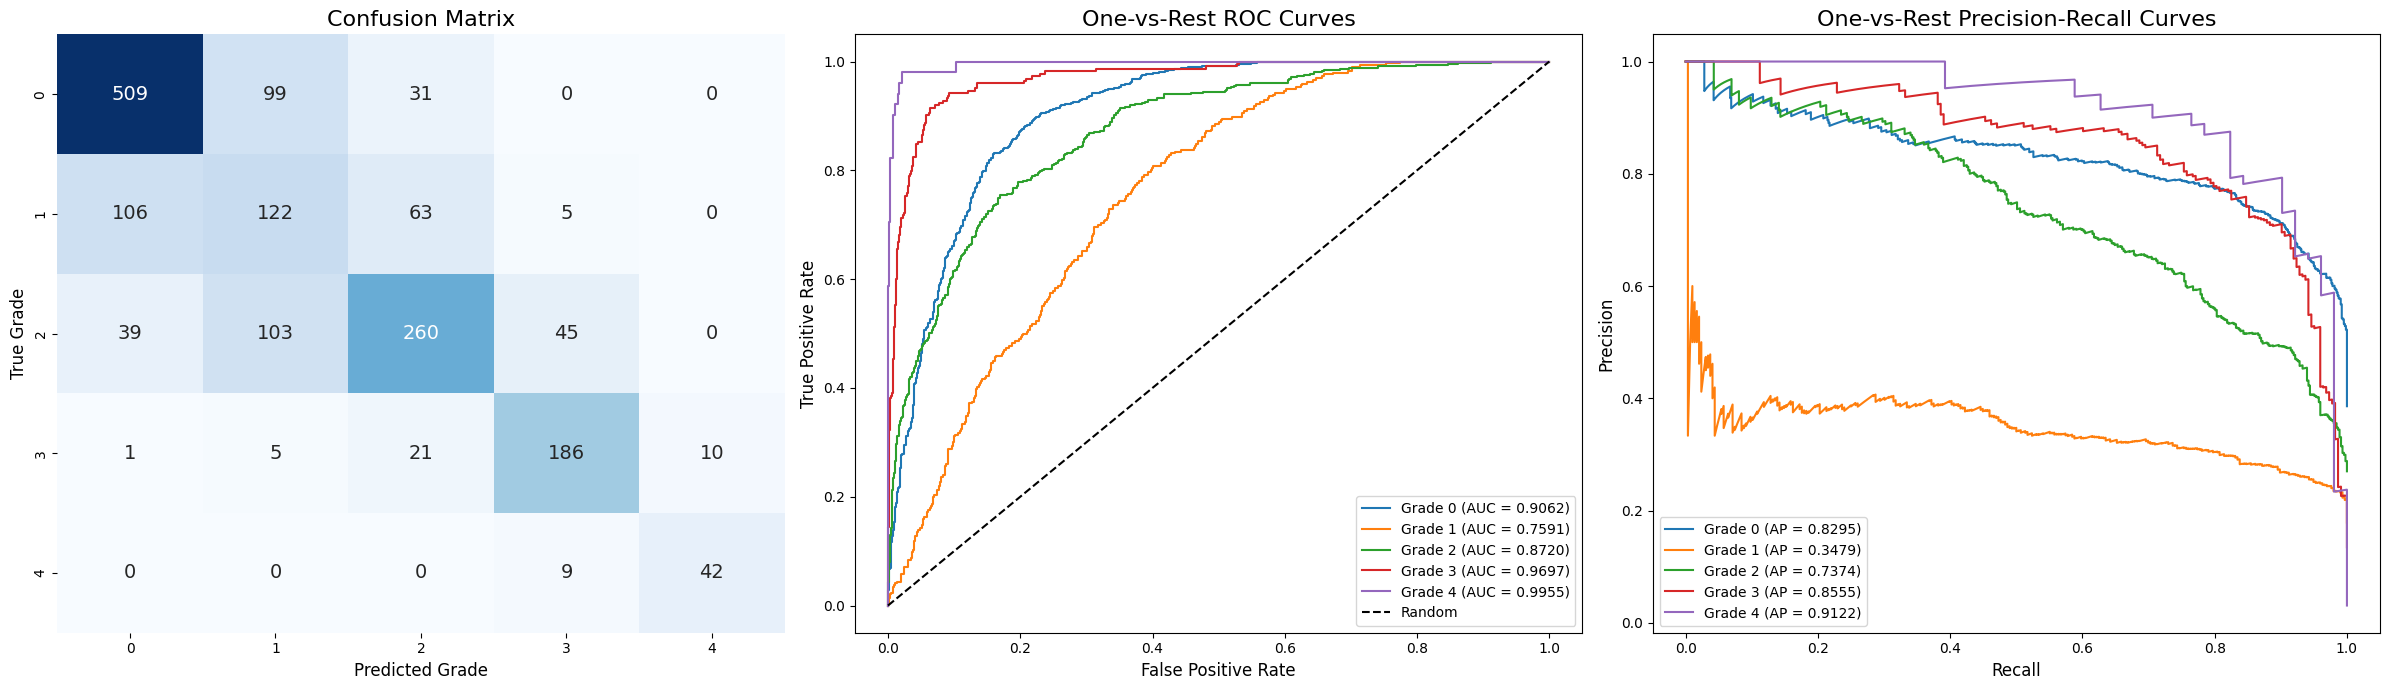

In [ ]:
# 3. Plotting Diagrams
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    has_sns = True
except ImportError:
    has_sns = False

plt.figure(figsize=(24, 7))

# Plot 1: Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_true, y_pred)
if has_sns:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[str(i) for i in range(5)], yticklabels=[str(i) for i in range(5)], cbar=False, annot_kws={"size": 14})
else:
    plt.imshow(cm, cmap='Blues')
    for i in range(5):
        for j in range(5):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black", fontsize=14)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Grade", fontsize=12)
plt.ylabel("True Grade", fontsize=12)

# Plot 2: ROC Curves (OVR)
plt.subplot(1, 3, 2)
for i in range(5):
    fpr, tpr, _ = roc_curve(y_one_hot[:, i], y_probas[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Grade {i} (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.title("One-vs-Rest ROC Curves", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc="lower right")

# Plot 3: Precision-Recall Curves (OVR)
plt.subplot(1, 3, 3)
for i in range(5):
    precision, recall, _ = precision_recall_curve(y_one_hot[:, i], y_probas[:, i])
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"Grade {i} (AP = {pr_auc:.4f})")
plt.title("One-vs-Rest Precision-Recall Curves", fontsize=16)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

## 13. Grad-CAM audit and saved failure comparisons

Grad-CAM targets the final normalized DenseNet feature tensor. The audit runs on
the complete labeled validation split after the best checkpoint is selected. It
exports every anatomy-gate failure as **original ROI | exact model input |
predicted-class Grad-CAM**. These proxy measurements diagnose attention; they
are not used for checkpoint selection and are not lesion annotations.


In [ ]:
def prepare_gradcam_input(image_path):
    """Return the untouched ROI, exact deterministic model input, and tensor."""
    image_bgr = cv2.imread(image_path)
    if image_bgr is None:
        raise IOError(f"Could not read image: {image_path}")
    original_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    spatial_transform = transforms.Compose([
        OpenCVCLAHE(clip_limit=TrainingConfig.clahe_clip_limit),
        SquarePadOpenCV(),
        transforms.ToPILImage(),
        transforms.Resize((TrainingConfig.crop_size, TrainingConfig.crop_size)),
    ])
    processed_rgb = np.asarray(spatial_transform(original_rgb))
    tensor = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        ),
    ])(processed_rgb).unsqueeze(0).to(device)
    return original_rgb, processed_rgb, tensor


class DenseNetGradCAM:
    """Gradient-weighted CAM from the final DenseNet `features.norm5` tensor."""

    def __init__(self, model):
        self.model = model
        self.activations = None
        self.gradients = None
        self.handle = model.gradcam_target_layer.register_forward_hook(self._capture)

    def _capture(self, module, inputs, output):
        self.activations = output

    def _capture_gradient(self, gradient):
        self.gradients = gradient

    def remove(self):
        self.handle.remove()

    def __call__(self, tensor, class_index=None):
        self.model.eval()
        self.model.zero_grad(set_to_none=True)
        self.activations = None
        self.gradients = None
        grad_tensor = tensor.detach().clone().requires_grad_(True)
        with torch.enable_grad():
            logits = self.model(grad_tensor)
            if class_index is None:
                class_index = int(logits.argmax(dim=1).item())
            if self.activations is None or not self.activations.requires_grad:
                raise RuntimeError("Grad-CAM target activation was not captured with gradients.")
            self.activations.register_hook(self._capture_gradient)
            logits[0, int(class_index)].backward()
        if self.gradients is None:
            raise RuntimeError("Grad-CAM gradients were not captured.")
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(
            cam,
            size=tensor.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )[0, 0].detach().float().cpu().numpy()
        maximum = float(cam.max())
        if maximum > 1e-8:
            cam = cam / maximum
        else:
            cam = np.zeros_like(cam)
        return logits.detach(), int(class_index), cam


def gradcam_energy_summary(cam):
    """Compute the same fixed geometry proxies used by the production audit."""
    height, width = cam.shape
    joint_mask = np.zeros_like(cam, dtype=bool)
    joint_mask[
        int(0.28 * height):int(0.72 * height),
        int(0.06 * width):int(0.94 * width),
    ] = True
    border_mask = np.ones_like(cam, dtype=bool)
    border_mask[
        int(0.08 * height):int(0.92 * height),
        int(0.08 * width):int(0.92 * width),
    ] = False
    lower_tibia_mask = np.zeros_like(cam, dtype=bool)
    lower_tibia_mask[int(0.72 * height):, :] = True
    total = float(cam.sum()) + 1e-8
    peak_y, peak_x = np.unravel_index(np.argmax(cam), cam.shape)
    return {
        "joint_energy": float(cam[joint_mask].sum() / total),
        "border_energy": float(cam[border_mask].sum() / total),
        "lower_tibia_energy": float(cam[lower_tibia_mask].sum() / total),
        "peak_x": float(peak_x / max(1, width - 1)),
        "peak_y": float(peak_y / max(1, height - 1)),
        "peak_inside_joint": bool(joint_mask[peak_y, peak_x]),
    }


def gradcam_failure_reasons(metrics):
    reasons = []
    if metrics["joint_energy"] < 0.55:
        reasons.append("low_joint_energy")
    if metrics["border_energy"] > 0.25:
        reasons.append("high_border_energy")
    if metrics["lower_tibia_energy"] > 0.25:
        reasons.append("high_lower_tibia_energy")
    if not metrics["peak_inside_joint"]:
        reasons.append("peak_outside_joint")
    return reasons


In [ ]:
def gradcam_overlay(processed_rgb, cam, alpha=0.40):
    heatmap = cv2.applyColorMap(np.uint8(np.clip(cam, 0, 1) * 255), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(processed_rgb, 1.0 - alpha, heatmap, alpha, 0)


def save_gradcam_comparison(original_rgb, processed_rgb, cam, row, save_path):
    """Save original ROI, exact input, and predicted-class Grad-CAM side by side."""
    figure, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(original_rgb)
    axes[0].set_title(f"Original labeled ROI | true G{row['true_grade']}")
    axes[1].imshow(processed_rgb)
    axes[1].set_title("CLAHE 1.25 -> square pad -> 384")
    axes[2].imshow(gradcam_overlay(processed_rgb, cam))
    axes[2].set_title(
        f"Grad-CAM predicted G{row['predicted_grade']} | p={row['confidence']:.3f}"
    )
    for axis in axes:
        axis.axis("off")
    reasons = row["failure_reasons"] or "gate_pass"
    figure.suptitle(
        f"joint={row['joint_energy']:.3f}, border={row['border_energy']:.3f}, "
        f"lower={row['lower_tibia_energy']:.3f} | {reasons}",
        fontsize=10,
    )
    figure.tight_layout()
    figure.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.close(figure)


def write_gradcam_csv(path, rows):
    if not rows:
        with open(path, "w", encoding="utf-8") as handle:
            handle.write("")
        return
    with open(path, "w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)


In [ ]:
# Load the best standard CE checkpoint and audit all labeled validation ROIs.
import csv
import json
from collections import Counter

loss_type_current = TrainingConfig.loss_stage3
best_model = DenseNet121Model(
    num_classes=TrainingConfig.num_classes,
    pretrained=False,
    loss_type=loss_type_current,
).to(device)

best_weight_path = stage3_best_path
if not os.path.exists(best_weight_path):
    raise FileNotFoundError(f"Final model checkpoint not found: {best_weight_path}")

try:
    checkpoint = torch.load(best_weight_path, map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load(best_weight_path, map_location=device)
if checkpoint.get("architecture") != TrainingConfig.architecture:
    raise RuntimeError(
        f"Checkpoint architecture {checkpoint.get('architecture')!r} does not match "
        f"{TrainingConfig.architecture!r}."
    )
if checkpoint.get("loss_type") != "ce":
    raise RuntimeError(f"Expected CE checkpoint, received {checkpoint.get('loss_type')!r}.")

best_model.load_state_dict(checkpoint.get("model_state_dict", checkpoint), strict=True)
best_model.eval()
gradcam_engine = DenseNetGradCAM(best_model)

gradcam_output_dir = os.path.join(CHECKPOINT_SAVE_DIR, "gradcam_validation_audit")
gradcam_failure_dir = os.path.join(gradcam_output_dir, "failed")
gradcam_success_dir = os.path.join(gradcam_output_dir, "representative_success")
os.makedirs(gradcam_failure_dir, exist_ok=True)
os.makedirs(gradcam_success_dir, exist_ok=True)

gradcam_rows = []
failed_gradcam_rows = []
successful_grade_examples = set()
failed_figure_paths = []
success_figure_paths = []

for index, (image_path, true_grade) in enumerate(
    tqdm.tqdm(
        list(zip(val_dataset.image_paths, val_dataset.labels)),
        desc="Grad-CAM validation audit",
    )
):
    original_rgb, processed_rgb, tensor = prepare_gradcam_input(image_path)
    logits, predicted_grade, cam = gradcam_engine(tensor)
    probabilities = F.softmax(logits.float(), dim=1)[0]
    metrics = gradcam_energy_summary(cam)
    reasons = gradcam_failure_reasons(metrics)
    row = {
        "dataset_index": index,
        "filename": os.path.basename(image_path),
        "image_path": image_path,
        "true_grade": int(true_grade),
        "predicted_grade": int(predicted_grade),
        "correct": int(predicted_grade == int(true_grade)),
        "confidence": float(probabilities[predicted_grade].item()),
        "gate_pass": int(not reasons),
        "failure_reasons": ";".join(reasons),
        **metrics,
        "comparison_path": "",
    }
    gradcam_rows.append(row)

    if reasons:
        figure_path = os.path.join(
            gradcam_failure_dir,
            f"{index:04d}_true_G{int(true_grade)}_pred_G{predicted_grade}.jpg",
        )
        row["comparison_path"] = figure_path
        save_gradcam_comparison(original_rgb, processed_rgb, cam, row, figure_path)
        failed_gradcam_rows.append(row.copy())
        failed_figure_paths.append(figure_path)
    elif int(true_grade) not in successful_grade_examples:
        successful_grade_examples.add(int(true_grade))
        figure_path = os.path.join(
            gradcam_success_dir,
            f"true_G{int(true_grade)}_pred_G{predicted_grade}.jpg",
        )
        save_gradcam_comparison(original_rgb, processed_rgb, cam, row, figure_path)
        success_figure_paths.append(figure_path)

gradcam_engine.remove()
gradcam_all_csv_path = os.path.join(gradcam_output_dir, "all_cases.csv")
gradcam_failure_csv_path = os.path.join(gradcam_output_dir, "failed_cases.csv")
write_gradcam_csv(gradcam_all_csv_path, gradcam_rows)
write_gradcam_csv(gradcam_failure_csv_path, failed_gradcam_rows)


def save_gradcam_montages(paths, prefix, rows_per_page=6):
    montage_paths = []
    for page, start in enumerate(range(0, len(paths), rows_per_page), start=1):
        tiles = []
        for path in paths[start:start + rows_per_page]:
            tile = cv2.imread(path)
            if tile is None:
                raise IOError(f"Could not read Grad-CAM comparison: {path}")
            tiles.append(cv2.resize(tile, (1200, 400), interpolation=cv2.INTER_AREA))
        montage_path = os.path.join(gradcam_output_dir, f"{prefix}_{page:02d}.jpg")
        if not cv2.imwrite(montage_path, np.vstack(tiles)):
            raise RuntimeError(f"Could not write montage: {montage_path}")
        montage_paths.append(montage_path)
    return montage_paths


gradcam_failed_montages = save_gradcam_montages(
    failed_figure_paths, "failed_gradcam_montage"
)
gradcam_success_montages = save_gradcam_montages(
    success_figure_paths, "successful_gradcam_montage"
)
gradcam_failure_rate = len(failed_gradcam_rows) / max(1, len(gradcam_rows))
failure_reason_counts = Counter(
    reason
    for row in failed_gradcam_rows
    for reason in row["failure_reasons"].split(";")
    if reason
)
grade_failure_counts = Counter(row["true_grade"] for row in failed_gradcam_rows)

if gradcam_failure_rate <= TrainingConfig.gradcam_max_failure_rate_for_roi_hypothesis:
    gradcam_interpretation = (
        "Grad-CAM failures are uncommon on labeled Kaggle ROIs. This supports, but "
        "does not prove, a production ROI/acquisition-domain mismatch. Inspect YOLO "
        "box geometry and production preprocessing independently before blaming YOLO."
    )
else:
    gradcam_interpretation = (
        "Grad-CAM failures are also present on labeled Kaggle ROIs. The classifier "
        "attention remains a material problem and production failures cannot be "
        "attributed to YOLO alone."
    )

gradcam_summary = {
    "cases": len(gradcam_rows),
    "gate_passes": len(gradcam_rows) - len(failed_gradcam_rows),
    "gate_failures": len(failed_gradcam_rows),
    "gate_failure_rate": gradcam_failure_rate,
    "failure_reasons": dict(failure_reason_counts),
    "failures_by_true_grade": dict(grade_failure_counts),
    "gate_thresholds": {
        "minimum_joint_energy": 0.55,
        "maximum_border_energy": 0.25,
        "maximum_lower_tibia_energy": 0.25,
        "peak_must_be_inside_joint": True,
    },
    "interpretation": gradcam_interpretation,
}
with open(os.path.join(gradcam_output_dir, "summary.json"), "w", encoding="utf-8") as handle:
    json.dump(gradcam_summary, handle, indent=2)

print(json.dumps(gradcam_summary, indent=2))
print(f"All Grad-CAM measurements: {gradcam_all_csv_path}")
print(f"Failed Grad-CAM comparisons: {gradcam_failure_dir}")
print(f"Failed Grad-CAM index: {gradcam_failure_csv_path}")
print(gradcam_interpretation)


Grad-CAM validation audit:   0%|          | 0/826 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()
Grad-CAM validation audit: 100%|██████████| 826/826 [01:03<00:00, 12.98it/s]


{
  "cases": 826,
  "gate_passes": 810,
  "gate_failures": 16,
  "gate_failure_rate": 0.01937046004842615,
  "failure_reasons": {
    "high_border_energy": 1,
    "high_lower_tibia_energy": 15,
    "low_joint_energy": 1,
    "peak_outside_joint": 1
  },
  "failures_by_true_grade": {
    "0": 1,
    "1": 6,
    "2": 7,
    "3": 2
  },
  "gate_thresholds": {
    "minimum_joint_energy": 0.55,
    "maximum_border_energy": 0.25,
    "maximum_lower_tibia_energy": 0.25,
    "peak_must_be_inside_joint": true
  },
  "interpretation": "Grad-CAM failures are uncommon on labeled Kaggle ROIs. This supports, but does not prove, a production ROI/acquisition-domain mismatch. Inspect YOLO box geometry and production preprocessing independently before blaming YOLO."
}
All Grad-CAM measurements: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-27_04-05-44_234349_UTC_natural_orientation_ce_gradcam/gradcam_validation_audit/all_cases.csv
Failed Grad-CAM comparisons: /content/drive/MyDrive/Model

In [ ]:
# =========================================================================
# 14. DIAGNOSTIC ERROR ANALYSIS & CRITICAL MISS DETECTOR
# =========================================================================
import os
import shutil
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm

def run_error_analysis(model, val_loader, dataset_root, output_dir=None):
    """
    Diagnoses misclassifications on the validation set, copying critical failure
    cases (e.g. underpredicted severe OA) to categorized diagnostic folders for inspection.
    """
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    # Create subfolders for specific failure categories
    categories = [
        "critical_miss_underpredict",  # True Grade 3/4 predicted as 0/1
        "critical_miss_overpredict",   # True Grade 0/1 predicted as 3/4
        "boundary_confusion",          # Confusions off by exactly 1 grade
        "other_errors"                 # The rest of the mismatches
    ]
    
    if output_dir is None:
        output_dir = os.path.join(TrainingConfig.checkpoint_dir, "error_analysis_diagnostics")
    shutil.rmtree(output_dir, ignore_errors=True)
    os.makedirs(output_dir, exist_ok=True)
    for cat in categories:
        os.makedirs(os.path.join(output_dir, cat), exist_ok=True)
        
    error_log = []
    dataset = val_loader.dataset
    
    # Get correct prediction function depending on loss type
    loss_type = TrainingConfig.loss_stage3 if TrainingConfig.training_pipeline == "3-stage" else TrainingConfig.loss_standard
    predict_fn = get_prediction_helper(loss_type)
    
    print("\n[Diagnostic Engine] Running batch inference on validation set...")
    with torch.no_grad():
        for idx, (images, targets) in enumerate(tqdm(val_loader)):
            images = images.to(device)
            outputs = model(images)
            preds = predict_fn(outputs).cpu().numpy()
            targets = targets.cpu().numpy()
            
            # Extract probabilities
            if loss_type in ["corn", "focal_corn", "threshold", "coral"]:
                # Sigmoid activation for ordinal models
                probs = torch.sigmoid(outputs).cpu().numpy()
            else:
                # Softmax activation for standard CrossEntropy
                probs = torch.softmax(outputs, dim=1).cpu().numpy()
                
            for i in range(len(preds)):
                pred = int(preds[i])
                target = int(targets[i])
                
                if pred != target:
                    # Map back to the absolute original image path
                    global_idx = idx * val_loader.batch_size + i
                    if global_idx < len(dataset):
                        img_path = dataset.image_paths[global_idx]
                        
                        # Categorize the severity of the failure
                        if target in [3, 4] and pred in [0, 1]:
                            cat = "critical_miss_underpredict"
                        elif target in [0, 1] and pred in [3, 4]:
                            cat = "critical_miss_overpredict"
                        elif abs(target - pred) == 1:
                            cat = "boundary_confusion"
                        else:
                            cat = "other_errors"
                            
                        # Generate formatted diagnostic file name
                        img_name = os.path.basename(img_path)
                        prob_val = probs[i][pred] if pred < len(probs[i]) else 0.0
                        new_name = f"true_G{target}_pred_G{pred}_conf_{prob_val:.2f}_{img_name}"
                        dest_path = os.path.join(output_dir, cat, new_name)
                        
                        # Copy original image to the correct category subfolder
                        shutil.copy(img_path, dest_path)
                        
                        error_log.append({
                            "filename": img_name,
                            "original_path": img_path,
                            "true_grade": target,
                            "predicted_grade": pred,
                            "confidence": prob_val,
                            "error_category": cat
                        })
                        
    df_errors = pd.DataFrame(error_log)
    csv_path = os.path.join(output_dir, "error_analysis_log.csv")
    df_errors.to_csv(csv_path, index=False)
    
    # Output Summary Diagnostics to Console
    print("\n" + "="*60)
    print("          DIAGNOSTIC ERROR ANALYSIS RESULTS")
    print("="*60)
    print(f"Total Validation Failures: {len(df_errors)} / {len(dataset)} ({len(df_errors)/len(dataset)*100:.2f}% error)")
    
    if not df_errors.empty:
        print("\nDistribution by Severity Category:")
        print(df_errors["error_category"].value_counts().to_string())
        
        print("\nTop 5 Most Common Confusions (True vs Pred):")
        confusion_matrix_summary = df_errors.groupby(["true_grade", "predicted_grade"]).size().reset_index(name="count")
        print(confusion_matrix_summary.sort_values(by="count", ascending=False).head(5).to_string(index=False))
        
        print(f"\nSaved diagnostic images and CSV index to: {os.path.abspath(output_dir)}/")
    print("="*60)


In [ ]:
# Load best stage 3 model and analyze errors
best_model_path = stage3_best_path
if os.path.exists(best_model_path):
    print(f"Loading best model parameters from: {best_model_path}")
    try:
        checkpoint_s3 = torch.load(best_model_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint_s3 = torch.load(best_model_path, map_location=device)
    model.load_state_dict(checkpoint_s3['model_state_dict'])
    
    # Run the error analysis
    run_error_analysis(model, val_loader, DATASET_ROOT_PATH)
else:
    print(f"Error: SOTA Stage 3 weights not found at {best_model_path}. Run training first.")


Loading best model parameters from: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-27_04-05-44_234349_UTC_natural_orientation_ce_gradcam/best_model.pth

[Diagnostic Engine] Running batch inference on validation set...


100%|██████████| 18/18 [00:12<00:00,  1.43it/s]


          DIAGNOSTIC ERROR ANALYSIS RESULTS
Total Validation Failures: 288 / 826 (34.87% error)

Distribution by Severity Category:
error_category
boundary_confusion            242
other_errors                   34
critical_miss_overpredict       7
critical_miss_underpredict      5

Top 5 Most Common Confusions (True vs Pred):
 true_grade  predicted_grade  count
          0                1     80
          2                1     52
          1                0     48
          1                2     22
          2                0     22

Saved diagnostic images and CSV index to: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-27_04-05-44_234349_UTC_natural_orientation_ce_gradcam/error_analysis_diagnostics/


## Timestamped Natural-Orientation CE + Grad-CAM Report

The final cell writes the exact training configuration, classification results,
and complete Grad-CAM anatomy-gate summary into the timestamped run directory.


In [ ]:
# Export an exact timestamped Markdown report for this completed run.
import json
from sklearn.metrics import precision_recall_fscore_support, recall_score

try:
    selected_checkpoint = torch.load(
        stage3_best_path, map_location="cpu", weights_only=False
    )
except TypeError:
    selected_checkpoint = torch.load(stage3_best_path, map_location="cpu")
selected_validation_raw = selected_checkpoint.get("validation_metrics", {})
selected_validation = {}
for key, value in selected_validation_raw.items():
    if key in {"probas", "report"}:
        continue
    if isinstance(value, (np.floating, np.integer)):
        value = value.item()
    selected_validation[key] = value
test_precision, test_recall, test_f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=[0, 1, 2, 3, 4],
    average="macro",
    zero_division=0,
)
test_grade1_recall = recall_score(y_true == 1, y_pred == 1, zero_division=0)
manifest = {
    "run_timestamp": TrainingConfig.run_timestamp,
    "run_directory": TrainingConfig.checkpoint_dir,
    "architecture": TrainingConfig.architecture,
    "loss": "ce",
    "heatmap_method": "gradient_gradcam_features_norm5",
    "orientation_policy": "natural_no_inference_mirroring",
    "preprocessing": "CLAHE 1.25 -> SquarePad -> Resize 384",
    "augmentation": {
        "horizontal_flip_probability": TrainingConfig.horizontal_flip_p,
        "rotation_degrees": TrainingConfig.rotation_degrees,
        "brightness_jitter": TrainingConfig.brightness_jitter,
        "contrast_jitter": TrainingConfig.contrast_jitter,
        "random_erasing_probability": TrainingConfig.random_erasing_p,
    },
    "best_epoch": selected_checkpoint.get("epoch"),
    "selected_checkpoint": stage3_best_path,
    "validation_metrics": selected_validation,
    "test_metrics": {
        "accuracy": float(test_acc),
        "qwk": float(test_qwk),
        "macro_precision": float(test_precision),
        "macro_recall": float(test_recall),
        "macro_f1": float(test_f1),
        "grade1_recall": float(test_grade1_recall),
        "macro_ap": float(test_ap),
        "macro_auc": float(test_auc),
    },
    "gradcam_validation_audit": gradcam_summary,
}
with open(os.path.join(CHECKPOINT_SAVE_DIR, "run_manifest.json"), "w") as handle:
    json.dump(manifest, handle, indent=2)
with open(os.path.join(CHECKPOINT_SAVE_DIR, "SELECTED_CHECKPOINT.txt"), "w") as handle:
    handle.write(stage3_best_path + "\n")

report = f"""# DenseNet-121 Natural-Orientation CE + Grad-CAM Run Report

| Field | Value |
| --- | --- |
| Run timestamp | {TrainingConfig.run_timestamp} |
| Architecture | `{TrainingConfig.architecture}` |
| Loss | Five-class Cross-Entropy (CE) |
| Input | CLAHE 1.25 -> square padding -> resize {TrainingConfig.crop_size}; no crop |
| Batch size | {TrainingConfig.batch_size} |
| Sampler | Full inverse-frequency |
| Training stages | 5 epoch head warm-up; 15 epoch coarse tune; 10 epoch full fine-tune |
| Orientation | Natural; no deterministic inference mirroring |
| Horizontal flip | p={TrainingConfig.horizontal_flip_p:.2f}, training only |
| Heatmap | Gradient Grad-CAM from `features.norm5`; post-training diagnostic only |
| Checkpoint weights | Raw model weights; EMA disabled |
| Best epoch | {selected_checkpoint.get('epoch')} |
| Selected checkpoint | `{stage3_best_path}` |
| Grad-CAM artifacts | `{gradcam_output_dir}` |
| Failed comparisons | `{gradcam_failure_dir}` |

## Validation Selection Metrics

```json
{json.dumps(selected_validation, indent=2)}
```

## Test Metrics

| Accuracy | QWK | Macro Precision | Macro Recall | Macro F1 | Grade 1 Recall | AP | AUC |
| ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| {test_acc:.4f} | {test_qwk:.4f} | {test_precision:.4f} | {test_recall:.4f} | {test_f1:.4f} | {test_grade1_recall:.4f} | {test_ap:.4f} | {test_auc:.4f} |

## Grad-CAM Validation Audit

```json
{json.dumps(gradcam_summary, indent=2)}
```

{gradcam_interpretation}

Grad-CAM is a post-hoc explanation and not an expert lesion mask. A low failure
rate on Kaggle ROIs supports a production crop/domain-shift hypothesis, but does
not by itself prove that YOLO is responsible.
"""
report_path = os.path.join(CHECKPOINT_SAVE_DIR, "report.md")
with open(report_path, "w", encoding="utf-8") as handle:
    handle.write(report)
print(f"Run report saved: {report_path}")


Run report saved: /content/drive/MyDrive/Models/densenet121_checkpoints/2026-07-27_04-05-44_234349_UTC_natural_orientation_ce_gradcam/report.md


## Release Colab Runtime

The next cell releases the accelerator only after training, evaluation, Grad-CAM
artifact export, report generation, and diagnostics finish.


In [ ]:
# Release the Colab accelerator only after every export has completed.
try:
    from google.colab import runtime
    print("All notebook work completed. Releasing the Colab runtime...")
    runtime.unassign()
except ImportError:
    print("Not running in Google Colab; runtime release skipped.")


All notebook work completed. Releasing the Colab runtime...
